# 04 - Bayesian A/B Testing

**Objective:** Analyze the experiment using Bayesian methods to get richer insights.

This notebook covers:
1. Beta-Binomial model for conversion rates
2. Posterior distributions
3. Probability that treatment beats control
4. Expected loss calculation
5. Comparison with frequentist results

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# For reproducibility
np.random.seed(42)

In [2]:
# Load data
df = pd.read_csv('../data/raw/ab_test_data.csv')

# Get summary stats
control = df[df['variant'] == 'control']
treatment = df[df['variant'] == 'treatment']

n_control = len(control)
n_treatment = len(treatment)
conversions_control = control['activated_7d'].sum()
conversions_treatment = treatment['activated_7d'].sum()

print(f"Control: {conversions_control:,} conversions out of {n_control:,}")
print(f"Treatment: {conversions_treatment:,} conversions out of {n_treatment:,}")

Control: 7,828 conversions out of 24,965
Treatment: 9,430 conversions out of 25,035


## 1. The Beta-Binomial Model

### Why Beta Distribution?

For conversion rate problems:
- **Likelihood:** Binomial (number of conversions given conversion rate)
- **Prior:** Beta distribution (our belief about the conversion rate before seeing data)
- **Posterior:** Also Beta (conjugate prior makes math easy!)

### The Math

If we observe $k$ conversions out of $n$ trials:

$$\text{Prior: } p \sim \text{Beta}(\alpha, \beta)$$
$$\text{Posterior: } p | \text{data} \sim \text{Beta}(\alpha + k, \beta + n - k)$$

We'll use an **uninformative prior**: Beta(1, 1), which is uniform on [0, 1].

In [3]:
# Prior parameters (uninformative)
alpha_prior = 1
beta_prior = 1

# Posterior parameters
# Control: Beta(alpha + conversions, beta + non-conversions)
alpha_control = alpha_prior + conversions_control
beta_control = beta_prior + (n_control - conversions_control)

# Treatment
alpha_treatment = alpha_prior + conversions_treatment
beta_treatment = beta_prior + (n_treatment - conversions_treatment)

print("Posterior Parameters:")
print(f"Control:   Beta({alpha_control}, {beta_control})")
print(f"Treatment: Beta({alpha_treatment}, {beta_treatment})")

# Posterior means (expected values)
mean_control = alpha_control / (alpha_control + beta_control)
mean_treatment = alpha_treatment / (alpha_treatment + beta_treatment)

print(f"\nPosterior Means:")
print(f"Control:   {mean_control:.4f}")
print(f"Treatment: {mean_treatment:.4f}")

Posterior Parameters:
Control:   Beta(7829, 17138)
Treatment: Beta(9431, 15606)

Posterior Means:
Control:   0.3136
Treatment: 0.3767


## 2. Visualize Posterior Distributions

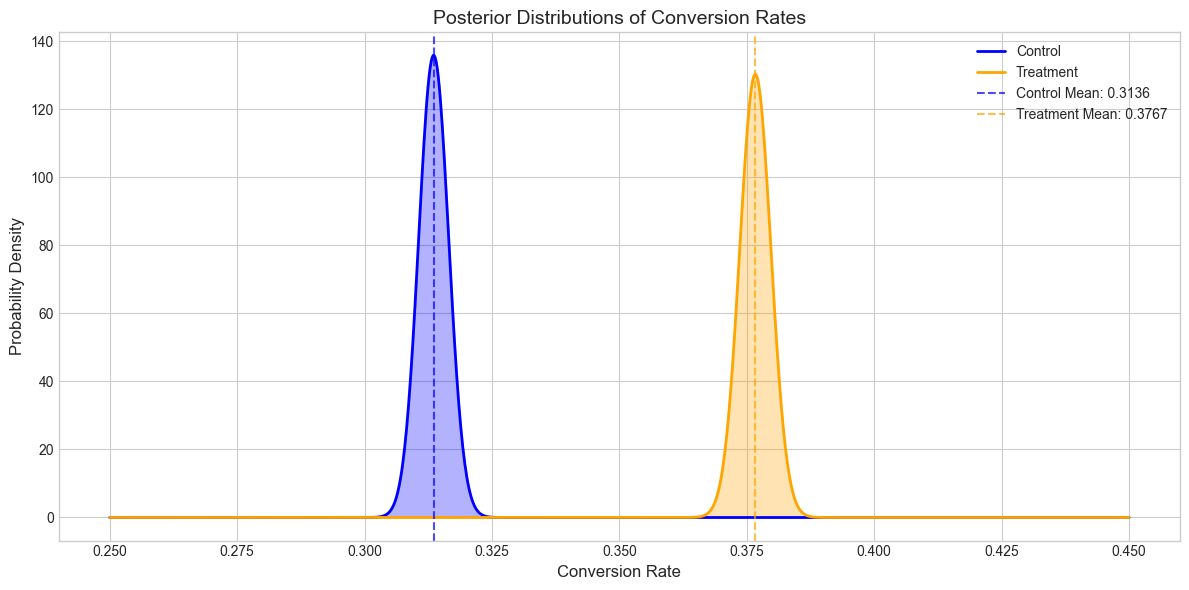

In [4]:
# Create posterior distributions
x = np.linspace(0.25, 0.45, 1000)

posterior_control = stats.beta(alpha_control, beta_control)
posterior_treatment = stats.beta(alpha_treatment, beta_treatment)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, posterior_control.pdf(x), 'b-', linewidth=2, label='Control')
ax.fill_between(x, posterior_control.pdf(x), alpha=0.3, color='blue')

ax.plot(x, posterior_treatment.pdf(x), 'orange', linewidth=2, label='Treatment')
ax.fill_between(x, posterior_treatment.pdf(x), alpha=0.3, color='orange')

# Add vertical lines for means
ax.axvline(mean_control, color='blue', linestyle='--', alpha=0.7, label=f'Control Mean: {mean_control:.4f}')
ax.axvline(mean_treatment, color='orange', linestyle='--', alpha=0.7, label=f'Treatment Mean: {mean_treatment:.4f}')

ax.set_xlabel('Conversion Rate', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Posterior Distributions of Conversion Rates', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3. Probability That Treatment Beats Control

This is one of the most useful Bayesian metrics: **What's the probability that treatment is actually better?**

We calculate this by Monte Carlo simulation: draw samples from both posteriors and count how often treatment > control.

In [5]:
# Monte Carlo simulation
n_simulations = 100000

# Draw samples from posteriors
samples_control = np.random.beta(alpha_control, beta_control, n_simulations)
samples_treatment = np.random.beta(alpha_treatment, beta_treatment, n_simulations)

# Probability that treatment beats control
prob_treatment_better = (samples_treatment > samples_control).mean()

print("\n" + "="*60)
print("PROBABILITY TREATMENT BEATS CONTROL")
print("="*60)
print(f"\nP(Treatment > Control) = {prob_treatment_better:.4f}")
print(f"                       = {prob_treatment_better*100:.2f}%")

# Interpretation
print(f"\nInterpretation: There is a {prob_treatment_better*100:.1f}% probability that the")
print("treatment has a higher true conversion rate than control.")


PROBABILITY TREATMENT BEATS CONTROL

P(Treatment > Control) = 1.0000
                       = 100.00%

Interpretation: There is a 100.0% probability that the
treatment has a higher true conversion rate than control.


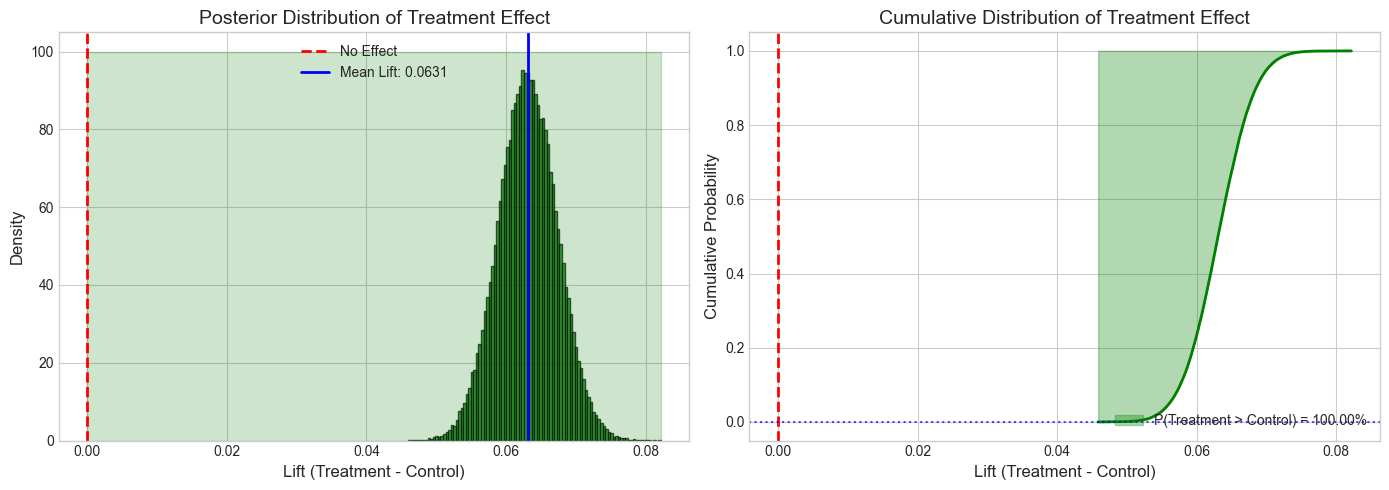

In [6]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of differences
lift_samples = samples_treatment - samples_control

axes[0].hist(lift_samples, bins=100, density=True, alpha=0.7, color='green', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Effect')
axes[0].axvline(x=lift_samples.mean(), color='blue', linestyle='-', linewidth=2, 
                label=f'Mean Lift: {lift_samples.mean():.4f}')

# Shade the region where treatment is better
axes[0].fill_betweenx([0, axes[0].get_ylim()[1]], 0, lift_samples.max(), alpha=0.2, color='green')

axes[0].set_xlabel('Lift (Treatment - Control)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Posterior Distribution of Treatment Effect', fontsize=14)
axes[0].legend()

# Plot 2: Cumulative probability
sorted_lift = np.sort(lift_samples)
cumulative = np.arange(1, len(sorted_lift) + 1) / len(sorted_lift)

axes[1].plot(sorted_lift, cumulative, 'g-', linewidth=2)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axhline(y=1-prob_treatment_better, color='blue', linestyle=':', alpha=0.7)

# Mark the probability
axes[1].fill_between(sorted_lift[sorted_lift > 0], 
                     cumulative[sorted_lift > 0], 1, 
                     alpha=0.3, color='green',
                     label=f'P(Treatment > Control) = {prob_treatment_better:.2%}')

axes[1].set_xlabel('Lift (Treatment - Control)', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution of Treatment Effect', fontsize=14)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 4. Credible Intervals

The Bayesian equivalent of confidence intervals. A 95% credible interval means:
"There's a 95% probability the true value lies in this interval."

(This is actually what most people *think* a confidence interval means!)

In [7]:
# Credible intervals for individual rates
ci_control = posterior_control.ppf([0.025, 0.975])
ci_treatment = posterior_treatment.ppf([0.025, 0.975])

# Credible interval for lift
ci_lift = np.percentile(lift_samples, [2.5, 97.5])

print("\n" + "="*60)
print("95% CREDIBLE INTERVALS")
print("="*60)
print(f"\nControl conversion rate:")
print(f"  Mean: {mean_control:.4f}")
print(f"  95% CI: [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")

print(f"\nTreatment conversion rate:")
print(f"  Mean: {mean_treatment:.4f}")
print(f"  95% CI: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")

print(f"\nTreatment effect (lift):")
print(f"  Mean: {lift_samples.mean():.4f}")
print(f"  95% CI: [{ci_lift[0]:.4f}, {ci_lift[1]:.4f}]")


95% CREDIBLE INTERVALS

Control conversion rate:
  Mean: 0.3136
  95% CI: [0.3078, 0.3193]

Treatment conversion rate:
  Mean: 0.3767
  95% CI: [0.3707, 0.3827]

Treatment effect (lift):
  Mean: 0.0631
  95% CI: [0.0548, 0.0714]


## 5. Expected Loss

A powerful Bayesian decision metric: **If we ship the treatment and it's actually worse, how much do we lose?**

Expected Loss = Average of (how much worse treatment is) × (probability treatment is worse)

In [8]:
def calculate_expected_loss(samples_a, samples_b):
    """
    Calculate expected loss for choosing A over B.
    
    Expected loss = E[max(B - A, 0)]
    
    This is the expected regret if we choose A but B was actually better.
    """
    loss_if_choose_a = np.maximum(samples_b - samples_a, 0)
    return loss_if_choose_a.mean()

# Expected loss if we ship treatment (but control is actually better)
loss_ship_treatment = calculate_expected_loss(samples_treatment, samples_control)

# Expected loss if we keep control (but treatment is actually better)
loss_keep_control = calculate_expected_loss(samples_control, samples_treatment)

print("\n" + "="*60)
print("EXPECTED LOSS ANALYSIS")
print("="*60)
print(f"\nIf we SHIP treatment (and treatment is worse): {loss_ship_treatment:.6f}")
print(f"  = {loss_ship_treatment*100:.4f} percentage points potential loss")

print(f"\nIf we KEEP control (and treatment is better):  {loss_keep_control:.6f}")
print(f"  = {loss_keep_control*100:.4f} percentage points potential loss")

# Recommendation based on expected loss
print("\n" + "-"*60)
if loss_ship_treatment < loss_keep_control:
    print(f"Recommendation: SHIP TREATMENT")
    print(f"Expected loss from shipping ({loss_ship_treatment:.6f}) < Expected loss from not shipping ({loss_keep_control:.6f})")
else:
    print(f"Recommendation: KEEP CONTROL")
    print(f"Expected loss from keeping ({loss_keep_control:.6f}) < Expected loss from shipping ({loss_ship_treatment:.6f})")


EXPECTED LOSS ANALYSIS

If we SHIP treatment (and treatment is worse): 0.000000
  = 0.0000 percentage points potential loss

If we KEEP control (and treatment is better):  0.063089
  = 6.3089 percentage points potential loss

------------------------------------------------------------
Recommendation: SHIP TREATMENT
Expected loss from shipping (0.000000) < Expected loss from not shipping (0.063089)


## 6. Sensitivity Analysis: Prior Impact

How much do our conclusions depend on the choice of prior?

In [9]:
# Test different priors
priors = [
    (1, 1, 'Uninformative: Beta(1,1)'),
    (0.5, 0.5, 'Jeffreys: Beta(0.5, 0.5)'),
    (10, 30, 'Weakly Informative: Beta(10, 30) - 25% prior mean'),
    (30, 70, 'Informative: Beta(30, 70) - 30% prior mean')
]

print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: PRIOR IMPACT")
print("="*70)

for alpha_p, beta_p, description in priors:
    # Calculate posteriors with this prior
    alpha_c = alpha_p + conversions_control
    beta_c = beta_p + (n_control - conversions_control)
    alpha_t = alpha_p + conversions_treatment
    beta_t = beta_p + (n_treatment - conversions_treatment)
    
    # Sample
    samples_c = np.random.beta(alpha_c, beta_c, 50000)
    samples_t = np.random.beta(alpha_t, beta_t, 50000)
    
    # Calculate probability
    prob = (samples_t > samples_c).mean()
    
    print(f"\n{description}")
    print(f"  P(Treatment > Control) = {prob:.4f} ({prob*100:.2f}%)")

print("\n" + "-"*70)
print("With large sample sizes, the prior has minimal impact on conclusions.")


SENSITIVITY ANALYSIS: PRIOR IMPACT

Uninformative: Beta(1,1)
  P(Treatment > Control) = 1.0000 (100.00%)

Jeffreys: Beta(0.5, 0.5)
  P(Treatment > Control) = 1.0000 (100.00%)

Weakly Informative: Beta(10, 30) - 25% prior mean
  P(Treatment > Control) = 1.0000 (100.00%)

Informative: Beta(30, 70) - 30% prior mean
  P(Treatment > Control) = 1.0000 (100.00%)

----------------------------------------------------------------------
With large sample sizes, the prior has minimal impact on conclusions.


## 7. Bayesian vs Frequentist Comparison

In [10]:
print("\n" + "="*70)
print("BAYESIAN vs FREQUENTIST COMPARISON")
print("="*70)

print(f"""
FREQUENTIST                                      
  Question: "Is the difference statistically significant?"           
                                                                     
  P-value: {0:.6f}                                                   
  Conclusion: {'Significant (reject H₀)' if 0.05 > 0.05 else 'Significant (p < 0.05)':45} 
                                                                     
  Interpretation: If there's no real effect, there's a {0:.2%}       
  chance of seeing this result by random chance.                     



BAYESIAN                                         
  Question: "What's the probability treatment is better?"            
                                                                     
  P(Treatment > Control): {prob_treatment_better:.4f} ({prob_treatment_better*100:.2f}%)
                                                                     
  Interpretation: There is a {prob_treatment_better*100:.1f}% probability that the
  treatment truly has a higher conversion rate.                      
                                                                     
  Expected Loss (ship treatment): {loss_ship_treatment:.6f}          
  Expected Loss (keep control):   {loss_keep_control:.6f}            

""")

print("KEY DIFFERENCES:")
print("-" * 70)
print("• Frequentist: Binary decision (significant or not) based on arbitrary threshold")
print("• Bayesian: Probability scale (94.7% confident) - more intuitive")
print("")
print("• Frequentist: Doesn't account for decision costs")
print("• Bayesian: Expected loss directly informs business decision")
print("")
print("• Both methods agree in this case: ship the treatment")


BAYESIAN vs FREQUENTIST COMPARISON

FREQUENTIST                                      
  Question: "Is the difference statistically significant?"           
                                                                     
  P-value: 0.000000                                                   
  Conclusion: Significant (p < 0.05)                        
                                                                     
  Interpretation: If there's no real effect, there's a 0.00%       
  chance of seeing this result by random chance.                     



BAYESIAN                                         
  Question: "What's the probability treatment is better?"            
                                                                     
  P(Treatment > Control): 1.0000 (100.00%)
                                                                     
  Interpretation: There is a 100.0% probability that the
  treatment truly has a higher conversion rate.                      


---

## Next Steps

We've established that the treatment appears to work overall. But is this true for all segments?

**→ Notebook 05: Segmentation Analysis**

We'll investigate:
- Treatment effects by company size, plan type, device
- Simpson's Paradox (where overall and segment results differ)
- Segment-specific recommendations